# PREDICTING HIGH PAYING DATA SCIENCE ROLES IN 2026

## Problem Statement
* In a competitive AI job market,companies struggle to benchmark salaries.Can we predict whether an AI/Data Science role will be "High Paying" > $150k or "Standard Paying" <= $150k based on job title, experience, location and remote status.


## Aims of the project

1. **Analyse salary trends**:Explore how salary varies by job title, experience level, location, company size and remote status.
1. **Build predictive models**:Develop and compare classification models to predict salary level using role and profile features. 
1. **Identify key drivers**:Determine the top 3 factors that most influence whether a role is high paying.
1. **Provide actionable insights**:Offer recommendations for job seekers, HR teams and companies on how to position roles and careers for competitive compensation in 2026.


## Data Understanding

**Data Source**:[Kaggle](https://www.kaggle.com/datasets/uditjain13/ai-and-data-science-job-salaries-2026)

**Dataset Description**:This dataset contains 2026 AI and Data Science job postings with salary, job title, experience level, location, and remote status.Used to predict if a role is "High paying" > $150k.

**Key Columns**
1. 'job_title':Role name
1. 'experience_level':EN,MI,SE,EX
1. 'salary':Annual salary in USD
1. 'location': Job location
1. 'remote_ratio ':0,50,100
1. 'company_size':S,M,L

In [52]:
#Import the necessary libraries for cleaning and visualizing the data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns




In [53]:
#Load the dataset into a pandas DataFrame
df = pd.read_csv('AI AND DS.csv')
df.head(10)

,job_title,experience_level,employment_type,company_size,company_location,employee_residence,industry,remote_ratio,years_experience,education_level,...,ai_tools_hours_per_week,salary_currency,salary_usd,equity_offered_pct,bonus_pct,job_satisfaction_score,interviews_to_offer,switched_jobs_last_year,upskilling_hours_per_month,fears_ai_automation_score
0,Data Analyst,Lead,Part-time,S,IN,AU,Finance,0,14.4,Bachelors,...,12.5,INR,23844,0.505,11.6,5.5,8,True,2.2,7.4
1,Research Scientist,Senior,Full-time,L,US,US,Retail,50,7.6,Masters,...,2.1,USD,170132,0.054,2.9,7.0,3,False,8.2,5.3
2,Machine Learning Engineer,Entry,Full-time,M,US,US,Government,0,0.0,Bootcamp,...,5.1,USD,83059,0.191,7.5,5.9,1,False,2.8,6.8
3,Data Engineer,Senior,Full-time,M,BR,IN,Government,100,9.7,Masters,...,2.0,BRL,29531,0.102,9.3,5.6,5,False,7.8,5.0
4,Data Engineer,Mid,Full-time,M,US,US,Education,0,3.2,Bachelors,...,4.0,USD,70105,0.064,10.6,4.6,4,False,9.1,5.1
5,Analytics Engineer,Senior,Full-time,M,SG,SG,Finance,100,11.6,Masters,...,17.4,SGD,97827,0.131,12.2,7.9,3,False,12.2,4.3
6,Business Intelligence Analyst,Senior,Full-time,M,US,US,Technology,0,9.8,Bachelors,...,0.5,USD,120062,0.039,13.0,5.5,6,False,10.9,6.4
7,Data Analyst,Entry,Full-time,M,US,US,Retail,0,1.4,Masters,...,4.2,USD,64165,0.187,12.7,7.3,3,True,14.5,6.4
8,Research Scientist,Mid,Full-time,M,AU,AU,Finance,0,2.2,Masters,...,6.6,AUD,112968,0.036,11.0,7.7,3,False,3.0,2.3
9,Data Engineer,Entry,Part-time,L,GB,GB,Healthcare,0,2.8,Self-taught,...,2.0,GBP,26464,0.044,0.0,6.2,5,False,9.3,5.4


In [54]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 27 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   job_title                   5000 non-null   str    
 1   experience_level            5000 non-null   str    
 2   employment_type             5000 non-null   str    
 3   company_size                5000 non-null   str    
 4   company_location            5000 non-null   str    
 5   employee_residence          5000 non-null   str    
 6   industry                    5000 non-null   str    
 7   remote_ratio                5000 non-null   int64  
 8   years_experience            5000 non-null   float64
 9   education_level             5000 non-null   str    
 10  primary_language            5000 non-null   str    
 11  has_ml_in_title             5000 non-null   bool   
 12  manages_people              5000 non-null   bool   
 13  team_size                   5000 non-null   

,remote_ratio,years_experience,team_size,certifications_count,weekly_hours,ai_tools_hours_per_week,salary_usd,equity_offered_pct,bonus_pct,job_satisfaction_score,interviews_to_offer,upskilling_hours_per_month,fears_ai_automation_score
count,5000.00000,5000.000000,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,43.08000,8.361440,7.93620,1.820400,44.345400,8.437400,98605.406200,0.139020,10.802720,6.685320,5.230800,8.680740,4.846080
std,41.45428,4.820808,2.64793,1.344212,6.142761,5.503637,55369.310473,0.184243,5.152959,1.364302,2.412695,4.422549,1.725924
min,0.00000,0.000000,1.00000,0.000000,24.400000,0.000000,12000.000000,0.000000,0.000000,1.100000,1.000000,0.000000,1.000000
25%,0.00000,4.800000,6.00000,1.000000,40.100000,3.300000,55592.750000,0.017000,7.100000,5.800000,3.000000,5.600000,3.700000
50%,50.00000,8.100000,8.00000,2.000000,44.400000,8.500000,90572.000000,0.072000,10.600000,6.700000,5.000000,8.700000,4.800000
75%,100.00000,11.500000,10.00000,3.000000,48.500000,12.625000,129657.750000,0.175000,14.200000,7.600000,7.000000,11.700000,6.000000
max,100.00000,23.700000,19.00000,8.000000,67.300000,25.200000,372347.000000,1.264000,30.800000,10.000000,16.000000,26.200000,10.000000


## Data Cleaning

#### Handling missing values

In [55]:
#Check for missing values in the dataset and remove them if necessary
df.isnull().sum()
df.dropna(inplace=True)
df.isnull().sum()



job_title                     0
experience_level              0
employment_type               0
company_size                  0
company_location              0
employee_residence            0
industry                      0
remote_ratio                  0
years_experience              0
education_level               0
primary_language              0
has_ml_in_title               0
manages_people                0
team_size                     0
certifications_count          0
weekly_hours                  0
uses_ai_tools_daily           0
ai_tools_hours_per_week       0
salary_currency               0
salary_usd                    0
equity_offered_pct            0
bonus_pct                     0
job_satisfaction_score        0
interviews_to_offer           0
switched_jobs_last_year       0
upskilling_hours_per_month    0
fears_ai_automation_score     0
dtype: int64

#### Handling duplicates 

In [56]:
#Check for duplicate rows in the dataset and remove them if necessary
df.duplicated().sum()
df.drop_duplicates(inplace=True)
df.duplicated().sum()

np.int64(0)

#### Checking for the duplicates

In [57]:
#Check the data types of each column in the dataset
print(df.dtypes)

job_title                         str
experience_level                  str
employment_type                   str
company_size                      str
company_location                  str
employee_residence                str
industry                          str
remote_ratio                    int64
years_experience              float64
education_level                   str
primary_language                  str
has_ml_in_title                  bool
manages_people                   bool
team_size                       int64
certifications_count            int64
weekly_hours                  float64
uses_ai_tools_daily              bool
ai_tools_hours_per_week       float64
salary_currency                   str
salary_usd                      int64
equity_offered_pct            float64
bonus_pct                     float64
job_satisfaction_score        float64
interviews_to_offer             int64
switched_jobs_last_year          bool
upskilling_hours_per_month    float64
fears_ai_aut

## Exploratory Data Analysis

#### Univariate EDA
1. Histogram
1. Bar graph
1. pie Chart

#### Bivariate EDA
1. Box plot
1. Count plot
1. Scatter plot


#### Multivariate EDA
1. Pair plot
1. Heatmap




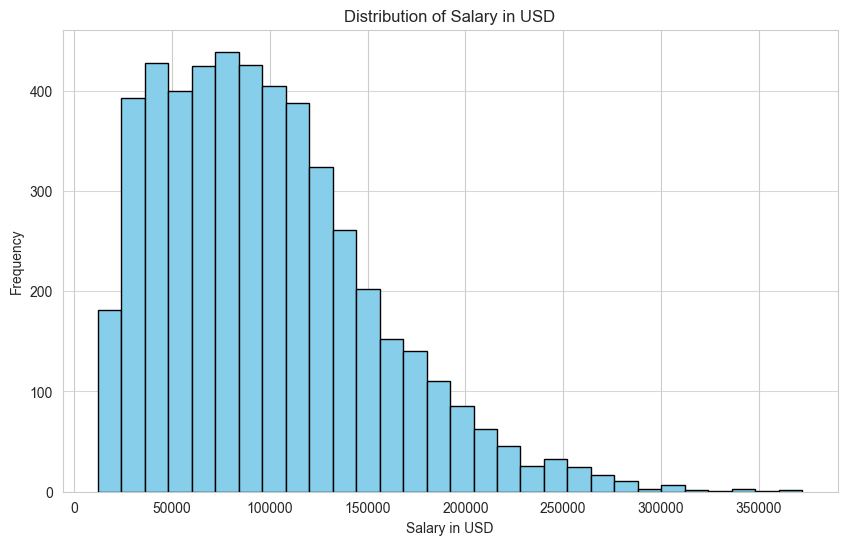

In [61]:
#Histogram of the 'Salary_USD' column
plt.figure(figsize=(10, 6))
plt.hist(df['salary_usd'], bins=30, color='skyblue', edgecolor='black')
plt.title('Distribution of Salary in USD')
plt.xlabel('Salary in USD')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

### Findings
1. **Most AI and Data Science jobs pay between $40k-$100k**:High paying jobs > $150k are uncommon and form a long right tail,making them a distinct minority class worth predicting.
1. **The market rate for most AI and Data Science roles sits between $50k-$100k**:Paying >$150k, puts the company in the top ~15-20% of payers which might end up making the company run bankrupt.

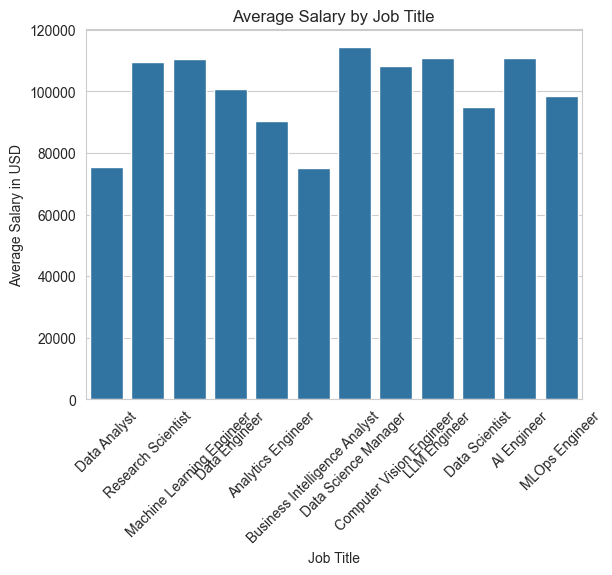

In [62]:
#Bar plot of the average salary by job title
sns.barplot(x='job_title', y='salary_usd', data=df, estimator=np.mean, ci=None)
plt.title('Average Salary by Job Title')
plt.xlabel('Job Title')
plt.ylabel('Average Salary in USD')
plt.xticks(rotation=45)
plt.show()

### Findings

1. **Job title matters a lot**:Research, ML, and BI roles average > $108k, while Analysts, and Analytics Engineer roles average > $80k.This means job_title will likely be a strong predictor for the salary given to the employees in 2026
1. **Business Intelligence Analysts**:Has the highest average salary, slightly above $110k.
1. **Research Scientists and Machine Learning Engineers**:Are also top earners, both averaging around $108k-$110k.


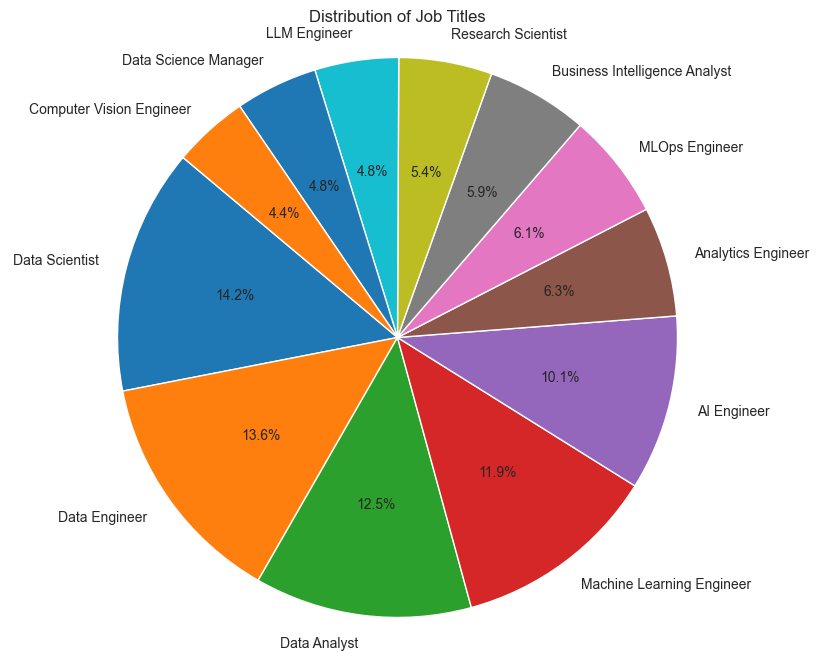

In [63]:
#Pie chart of the distribution of job titles in the dataset
plt.figure(figsize=(10, 8))
plt.pie(df['job_title'].value_counts(), labels=df['job_title'].value_counts().index, autopct='%1.1f%%', startangle=140)
plt.title('Distribution of Job Titles')
plt.axis('equal')
plt.show()

### Findings

1. The job market in this dataset is dominated by Data Scientists, Data Engineers, Data Analysts, and ML Engineer roles, while specialized roles like CV Engineer, Manager, and LLM Engineer are the least common.
1. **Highly imbalanced distribution**:A few roles dominate, while most roles are small slices thus making them valuable in the future and this might make their pay be of higher.


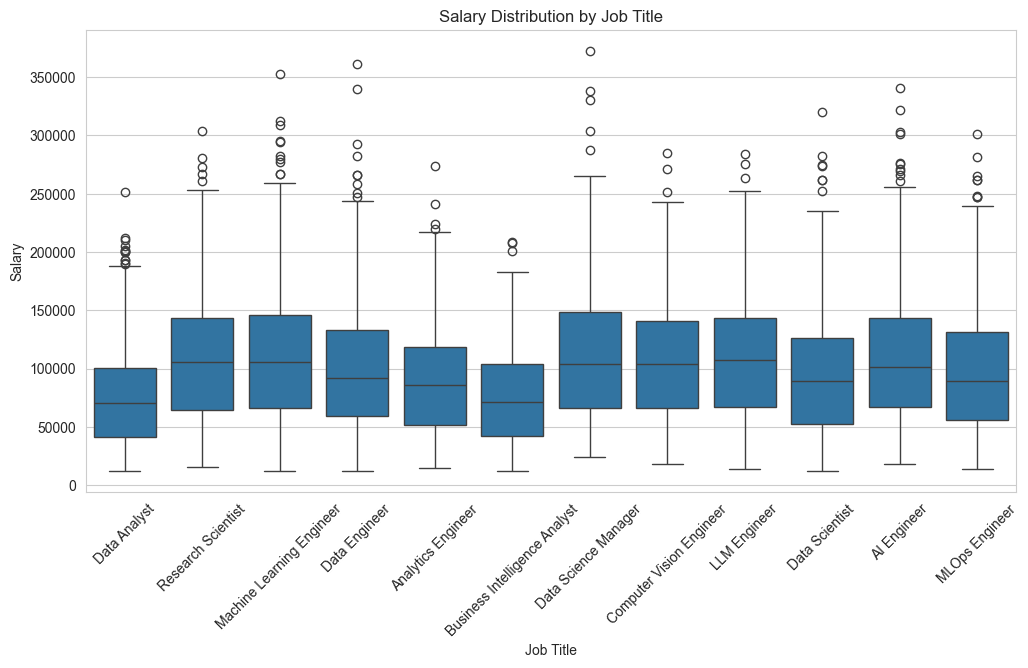

In [66]:
#Box plot of the salary distribution by job title
plt.figure(figsize=(12, 6))
sns.boxplot(x='job_title', y='salary_usd', data=df)
plt.title('Salary Distribution by Job Title')
plt.xlabel('Job Title')
plt.ylabel('Salary')
plt.xticks(rotation=45)
plt.show()


### Findings
1. Management + Emerging AI roles have the highest typical pay.Analyst roles have the lowest typical pay,
1. Even though Data Engineer median is mid ~$95k, it has huge upside.Data Science Manager has both high median and highest max.